In [1]:
import RandomTilingsV1 as RT1
import RandomTilings as RT

import numpy as np
import matplotlib.pyplot as plt
from time import time
from tqdm import trange

In [23]:
RT.config

Maximum Storage :   5.00 GB
Currently Used  : 156.25 KB
Free Storage    :   5.00 GB
Warnings        : Enabled
Hard Drive Mode : Disabled
MPL Backend     : Inline

# Timing of Reduction

In [2]:
weight_aztec = RT1.weight_aztec.weight_aztec
reduceV1 = RT1.algorithm_reduction_weight.algorithm_reduction_weight
shuffleV1 = RT1.shuffling.shuffling

In [3]:
red_V1   = []
red_V2   = []

shuf_V1  = []
shuf_V2  = []

w = np.array([[1.]])

max_n = 101
reps  = 20
for n in trange(1,max_n):
    t1 = time()
    for _ in range(reps):
        W  = weight_aztec(n,w)
        C = reduceV1(W)
    red_V1 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        M = shuffleV1(C)
    shuf_V1 += [(time()-t1)/reps]


    t1 = time()
    for _ in range(reps):
        A = RT.Aztec(n,w)
    red_V2 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        A.shuffle()
    shuf_V2 += [(time()-t1)/reps]

100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


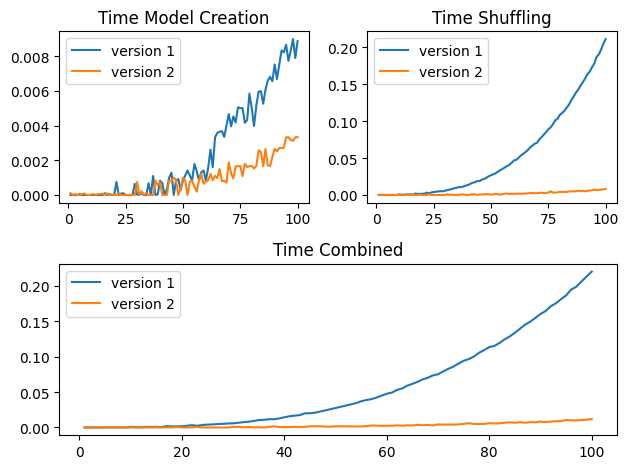

In [16]:
red_V1  = np.array(red_V1)
red_V2  = np.array(red_V2)

shuf_V1  = np.array(shuf_V1)
shuf_V2  = np.array(shuf_V2)

# Sample data
x = np.linspace(0, 10, 100)

# Create figure
fig = plt.figure()

# Define grid: 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# First row (two separate plots)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Second row (one plot spanning both columns)
ax3 = fig.add_subplot(gs[1, :])

# Plot something
ax1.set_title('Time Model Creation')
ax1.plot(range(1,len(red_V1)+1),red_V1,label = 'version 1')
ax1.plot(range(1,len(red_V2)+1),red_V2,label = 'version 2')
ax1.legend()

ax2.set_title('Time Shuffling')
ax2.plot(range(1,len(red_V1)+1),shuf_V1,label = 'version 1')
ax2.plot(range(1,len(red_V2)+1),shuf_V2,label = 'version 2')
ax2.legend()


ax3.set_title('Time Combined')
ax3.plot(range(1,len(red_V1)+1),shuf_V1+red_V1,label = 'version 1')
ax3.plot(range(1,len(red_V2)+1),shuf_V2+red_V2,label = 'version 2')
ax3.legend()

plt.tight_layout()
plt.show()



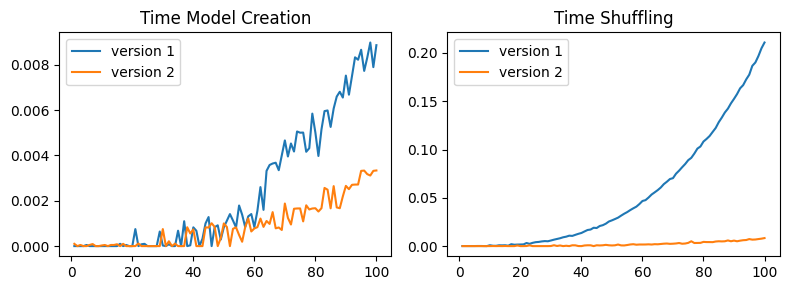

In [22]:
red_V1  = np.array(red_V1)
red_V2  = np.array(red_V2)

shuf_V1  = np.array(shuf_V1)
shuf_V2  = np.array(shuf_V2)

# Sample data
x = np.linspace(0, 10, 100)

# Create figure
fig = plt.figure(figsize=(8,3))

plt.subplot(121)
plt.title("Time Model Creation")
plt.plot(range(1,len(red_V1)+1),red_V1,label = 'version 1')
plt.plot(range(1,len(red_V2)+1),red_V2,label = 'version 2')
plt.legend()

plt.subplot(122)

plt.title('Time Shuffling')
plt.plot(range(1,len(red_V1)+1),shuf_V1,label = 'version 1')
plt.plot(range(1,len(red_V2)+1),shuf_V2,label = 'version 2')
plt.legend()


plt.tight_layout()
plt.show()


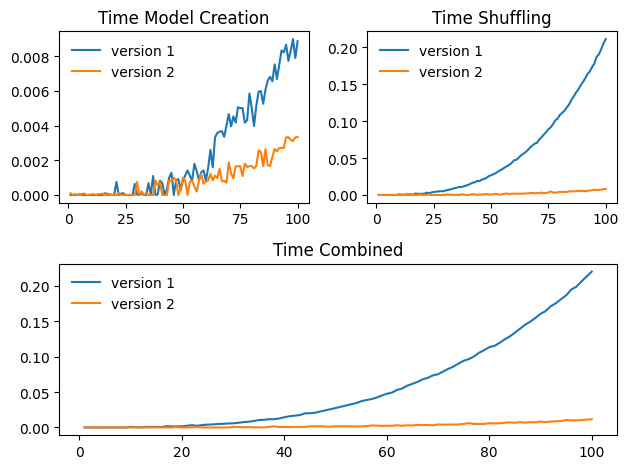

In [15]:
red_V1  = np.array(red_V1)
red_V2  = np.array(red_V2)

shuf_V1  = np.array(shuf_V1)
shuf_V2  = np.array(shuf_V2)

# Create figure
fig = plt.figure()

# Make figure background transparent
fig.patch.set_alpha(0)

# Define grid: 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# First row: two separate plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Second row: one plot spanning both columns
ax3 = fig.add_subplot(gs[1, :])

# Make subplot backgrounds transparent
for ax in [ax1, ax2, ax3]:
    ax.patch.set_alpha(0)

# Plot 1
ax1.set_title('Time Model Creation')
ax1.plot(range(1, len(red_V1) + 1), red_V1, label='version 1')
ax1.plot(range(1, len(red_V2) + 1), red_V2, label='version 2')
leg1 = ax1.legend()
leg1.get_frame().set_alpha(0)

# Plot 2
ax2.set_title('Time Shuffling')
ax2.plot(range(1, len(red_V1) + 1), shuf_V1, label='version 1')
ax2.plot(range(1, len(red_V2) + 1), shuf_V2, label='version 2')
leg2 = ax2.legend()
leg2.get_frame().set_alpha(0)

# Plot 3
ax3.set_title('Time Combined')
ax3.plot(range(1, len(red_V1) + 1), shuf_V1 + red_V1, label='version 1')
ax3.plot(range(1, len(red_V2) + 1), shuf_V2 + red_V2, label='version 2')
leg3 = ax3.legend()
leg3.get_frame().set_alpha(0)

plt.tight_layout()
plt.show()

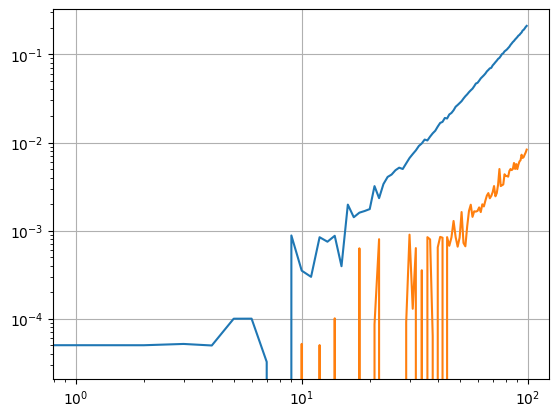

In [8]:
plt.plot(shuf_V1)
plt.plot(shuf_V2)

plt.loglog()
plt.grid()

C:\Users\u0173400\AppData\Local\Temp\ipykernel_12136\1175320078.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(shuf_V1/shuf_V2)
C:\Users\u0173400\AppData\Local\Temp\ipykernel_12136\1175320078.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(shuf_V1/shuf_V2)


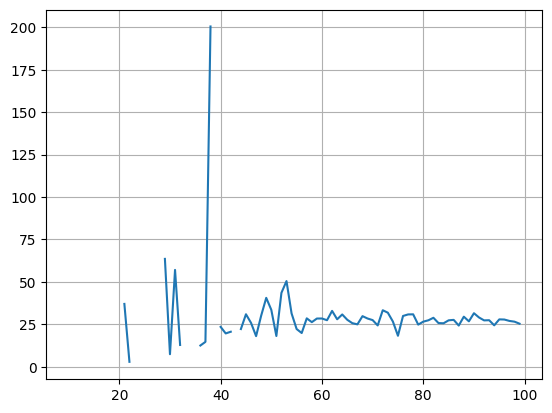

In [10]:
plt.plot(shuf_V1/shuf_V2)
plt.grid()